# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**:

Dataset users:

**‘city’**: 469 nulos (11.7%), proporción moderada. **Acción**: KEEP, imputar como NAN (valores nulos)

**‘churn_date’**: 3534 nulos (88.35%) proporción muy alta, son los usuarios que no han cancelado (siguen vigentes) no tienen fecha de churn . **Acción**: KEEP

Dataset usage:

**‘date’**: 50 nulos (0.12%), Muy pocos valores nulos. **Acción**: DROP o imputar con NAN
**‘duration’**: 22076 nulos (55.19%) proporción alta, ya que depende del tipo de evento 'type'. **Acción**: KEEP.
**‘length’**: 17896 nulos (44.74%) proporción alta, ya que depende del tipo de evento 'type'. **Acción**: KEEP.


💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



- La columna `user_id` Valores entre 10000 y 13999, sin inconsistencias.
- La columna `age`  Valores mínimos de -999, valor inválido, sentinel para datos faltantes. Además, la desviación estándar es inusualmente alta debido a este valor atípico. **Acción**: imputar este valor con la mediana.


In [14]:
# explorar columnas numéricas de usage
usage[['id','user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`tienen valores dentro de rangos consistentes.
- La columna `duration` presenta valores mínimos de 0, lo cual podría representar llamadas sin duración. Además de la alta proporción nulos (55.19%).

La columna `length`  presenta valores mínimos de 0 y una alta proporción de valores nulos (44.74%). Además, se observan valores máximos elevados, lo que podría indicar mensajes largos o concatenados.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [15]:
# explorar columnas categóricas de users
users[['city', 'plan']].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595



- La columna `city` ...presenta 7 categorías únicas y contiene valores faltantes (3531 de 4000 registros completos). La ciudad más frecuente es Bogotá. La presencia de valores nulos (~11.7%) indica la necesidad de imputación o etiquetado como "Unknown". No se observan valores inválidos evidentes, aunque se recomienda verificar consistencia en los nombres de las ciudades.
- La columna `plan` presenta 2 categorías únicas y no contiene valores nulos. El plan más frecuente es "Basico". No se identifican valores inválidos ni inconsistencias, por lo que la columna no requiere limpieza adicional.


In [16]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


- La columna `type` presenta 2 categorías únicas 'call' y 'text'. El valor más frecuente es "text", lo que indica que la mayoría de los registros corresponden a mensajes. 
 Conexión de variables
type = text (usar length)
type = call (usar duration)
Esto conecta con el análisis de nulos de las columnas 'duration' y 'length'


---
✍️ **Comentario**: 
- La columna `city` La presencia de valores nulos (~11.7%) indica la necesidad de reemplazar por nulos. No se observan valores inválidos.
- La columna `plan` El plan más frecuente es "Básico". No se identifican valores inválidos. 

- La columna `type` presenta 2 categorías únicas 'call' y 'text'. El valor más frecuente es "text", lo que indica que la mayoría de los registros corresponden a mensajes. 
 Conexión de variables
type = text (usar length)
type = call (usar duration)
Esto conecta con el análisis de nulos de las columnas 'duration' y 'length'

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  En las columnas categóricas, en la columna 'city' se encontraron valores inválidos o sentinels. 
- ¿Qué acción tomarías? Para ello se recurre a reemplazar por nulos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce") 

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] =  pd.to_datetime(usage['date'], errors="coerce") 

In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()  

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observa que la mayoría de los registros corresponden a los años 2022, 2023 y 2024. 
40 Registros del año 2026 (fechas imposibles).  ACCION: DROP.

In [20]:
# Revisar los años presentes en `date` de usage
users['reg_date'].dt.year.value_counts()  

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `date`, se observa que la mayoría de los registros corresponden a los años 2022, 2023 y 2024. 
40 Registros del año 2026 (fechas imposibles).  ACCION: DROP.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- Aparecen años imposibles con 40 registros en el año 2026.
- ACCION: DROP.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [24]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.


In [25]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [26]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Se analizó la relación entre la variable type y los valores nulos en `duration` y `length`. 
Se observó que para `duration`, los valores nulos se presentan casi exclusivamente cuando el tipo es text, mientras que para `length`, los valores nulos aparecen cuando el tipo es call.

Esto indica que los valores faltantes dependen directamente del tipo de evento, por lo que NO son errores, sino que representan datos no aplicables. En consecuencia, se clasifican como Missing At Random (MAR) y se decide mantener los valores nulos sin realizar imputación ni eliminación.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    "is_text":'sum', 
    "is_call":'sum', 
    "duration": 'sum',
}).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Renombrar columnas
usage_agg.columns =['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [32]:
# Resumen estadístico de las columnas numéricas
user_profile[['user_id', 'age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [33]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  

- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 


**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

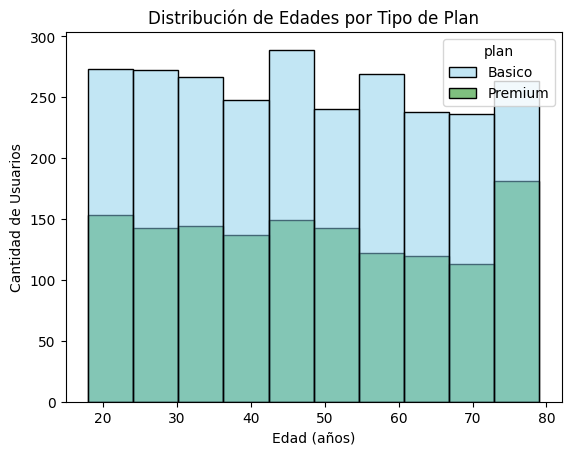

In [34]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', bins=10, 
             palette=['skyblue','green'], kde=False)
plt.xlabel('Edad (años)')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribución de Edades por Tipo de Plan')
plt.show()

💡Insights: 
- La distribución de edades es relativamente uniforme a lo largo de los rangos, sin una concentración marcada en un grupo específico, lo que indica que la base de usuarios es diversa en términos de edad.

- Se observa que el plan Básico tiene consistentemente una mayor cantidad de usuarios en todos los rangos de edad, mientras que el plan Premium mantiene una menor participación pero con una distribución similar. Esto sugiere que la edad no es un factor determinante en la elección del plan, sino que la preferencia por el plan Básico podría estar influenciada por otros factores como el precio o las necesidades de uso.
- Tiene un tipo de distribución simétrica.

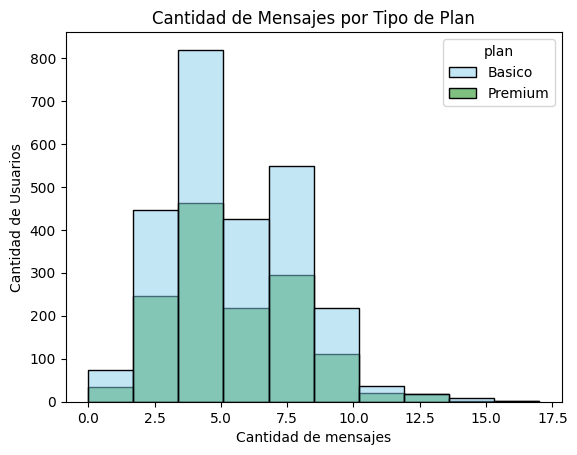

In [35]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=10, 
             palette=['skyblue','green'], kde=False)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.title('Cantidad de Mensajes por Tipo de Plan')
plt.show()

💡Insights: 
- El plan Básico presenta una mayor cantidad  de usuarios en todos los rangos de mensajes, lo cual es proporcional dentro del dataset.
-La proporción entre usuarios Básico y Premium se mantiene relativamente estable, por lo que el tipo de plan no parece ser un factor determinante en este tipo de uso.
- La distribución de la cantidad de mensajes está sesgada a la derecha, ya que la mayoría de los usuarios se concentra en rangos bajos de envío de mensajes (aprox. entre 1.7 y 8.5), mientras que pocos usuarios presentan volúmenes altos.

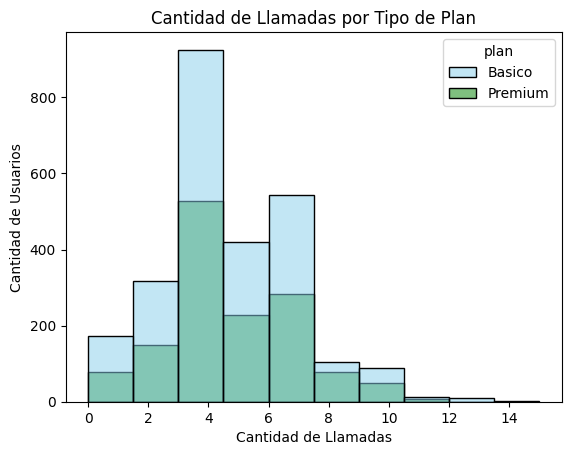

In [36]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=10, 
             palette=['skyblue','green'], kde=False)
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.title('Cantidad de Llamadas por Tipo de Plan')
plt.show()

💡Insights: 
- La distribución de la cantidad de llamadas presenta un sesgo a la derecha, ya que la mayoría de los usuarios se concentra en rangos bajos y medios de llamadas (aprox. entre 1.5 y 6.0), mientras que muy pocos usuarios realizan un número alto de llamadas.
- El plan Básico concentra la mayor cantidad de usuarios en todos los rangos de llamadas.
- En algunos rangos medios-altos (por ejemplo, entre 7.5 y 9.0 llamadas), se observa una ligera mayor participación relativa del plan Premium, lo que podría sugerir que los usuarios con mayor actividad telefónica tienden en cierta medida a optar por planes más completos.
- En los rangos más altos de llamadas (por encima de 10.5), la cantidad de usuarios es mínima en ambos planes, lo que indica que los comportamientos de uso intensivo son poco frecuentes.

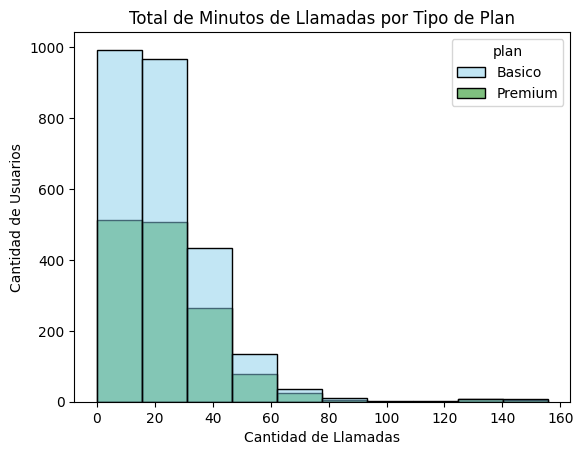

In [37]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=10, 
             palette=['skyblue','green'], kde=False)
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.title('Total de Minutos de Llamadas por Tipo de Plan')
plt.show()

💡Insights: 
- La distribución de minutos de llamadas presenta un fuerte sesgo a la derecha, ya que la gran mayoría de los usuarios se concentra en los rangos bajos de consumo, mientras que muy pocos usuarios presentan consumos elevados.
- El plan Básico concentra la mayor cantidad de usuarios en todos los rangos de minutos.
- En los rangos más altos de consumo (por encima de 120 minutos), se observa una mayor participación relativa del plan Premium. Esto sugiere que los usuarios con consumo intensivo de llamadas tienden a concentrarse en el plan Premium.

**Insights Finales:**
- Aunque la mayoría de los usuarios presenta un consumo bajo de minutos independientemente del plan, los usuarios con mayor intensidad de uso tienden a inclinarse hacia el plan Premium, lo que sugiere que este plan podría estar mejor alineado con necesidades de alto consumo.
- El plan Premium parece captar mejor a los usuarios de alto consumo, lo que representa una oportunidad para enfocar estrategias de marketing hacia usuarios Básico con patrones de uso crecientes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

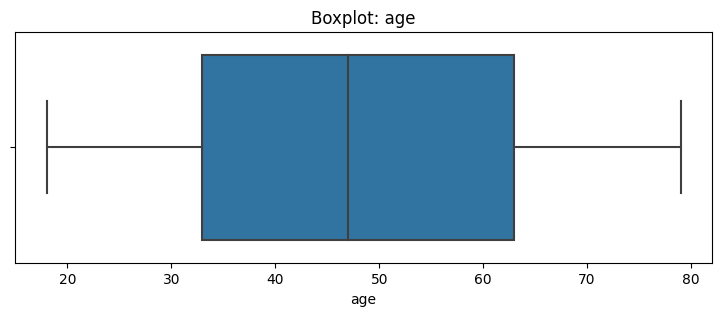

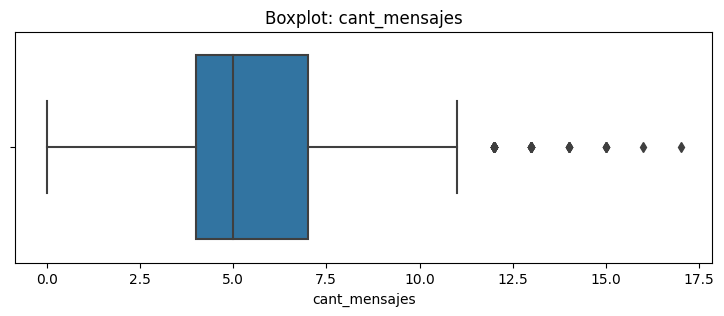

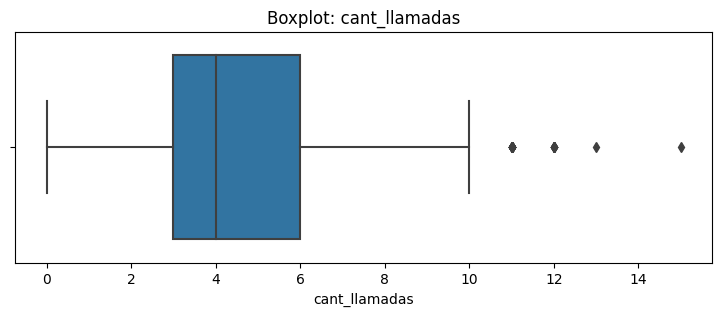

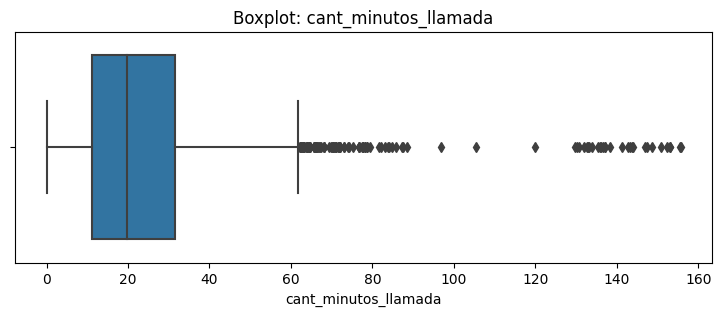

In [38]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(9,3))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 
- **Age**: No presenta outliers. Distribución uniforme entre 18-79 años, 
  lo que indica una base de clientes diversa sin concentraciones extremas.

- **cant_mensajes**: Presenta outliers ALTOS. Algunos usuarios envían 
  cantidades excepcionalmente altas de mensajes (posibles usuarios 
  comerciales o comportamiento atípico).

- **cant_llamadas**: Presenta outliers ALTOS. Usuarios con llamadas excesivas (posibles usuarios intensivos).

- **cant_minutos_llamada**: Presenta outliers ALTOS. Algunos usuarios 
  con duraciones de llamada extremadamente largas (posibles usuarios 
  comerciales o familiares).


In [39]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = user_profile[user_profile[col] > limite_superior]
    
    print(f"\n--- {col} ---")
    print(f"Límite superior: {limite_superior}")
    print(f"Valor máximo en datos: {user_profile[col].max()}")
    print(f"Cantidad de outliers: {len(outliers)}")


--- cant_mensajes ---
Límite superior: 11.5
Valor máximo en datos: 17.0
Cantidad de outliers: 46

--- cant_llamadas ---
Límite superior: 10.5
Valor máximo en datos: 15.0
Cantidad de outliers: 30

--- cant_minutos_llamada ---
Límite superior: 61.8575
Valor máximo en datos: 155.69
Cantidad de outliers: 109


In [40]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- **cant_mensajes:** 46 outliers por encima del límite superior (11.5), con un máximo de 17 mensajes. Sin embargo, estos valores no son extremadamente lejanos respecto al resto de la distribución, y representan un comportamiento posible de usuarios más activos. **Acción**: mantener los outliers, ya que reflejan variabilidad real del comportamiento y no parecen errores.

- **cant_llamadas:** 30 outliers por encima del límite superior (10.5), con un máximo de 15 llamadas. Estos valores, aunque superiores al promedio (4.47), no son excesivamente extremos y siguen siendo plausibles dentro del uso real de un servicio telefónico. **Acción**: mantener los outliers, ya que representan usuarios con mayor frecuencia de uso y no indican errores evidentes.

- **cant_minutos_llamada:** 109 outliers por encima del límite superior (61.86), con un valor máximo de 155.69 minutos. A diferencia de las otras variables, aquí los valores extremos son más dispersos y significativamente mayores respecto a la media (23.3), lo que indica una cola larga en la distribución. **Acción**: mantener los outliers, ya que representan usuarios de alto consumo, un segmento clave para el negocio. Eliminarlos o caparlos podría ocultar patrones relevantes para estrategias comerciales.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [44]:
def grupo_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']
    
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 20 and mensajes < 50:
        return 'Uso medio'
    else:
        return 'Alto uso'

# Aplicar la función
user_profile['grupo_uso'] = user_profile.apply(grupo_uso, axis=1)

In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Uso medio
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Uso medio
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [46]:
# Crear columna grupo_edad
def grupo_edad(row):
    age = row['age']
    
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Aplicar la función
user_profile['grupo_edad'] = user_profile.apply(grupo_edad, axis=1)


In [47]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Uso medio,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Uso medio,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

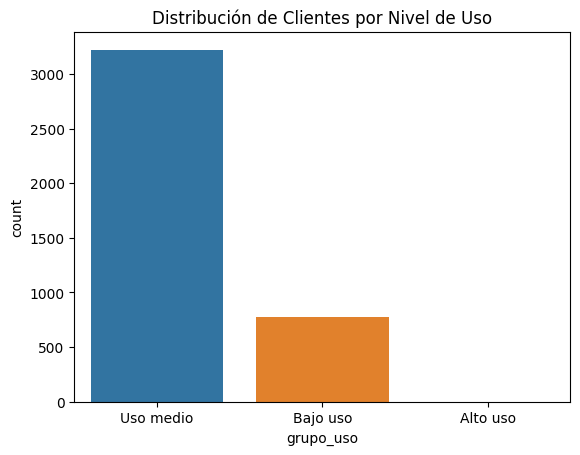

In [49]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Clientes por Nivel de Uso')

plt.show()

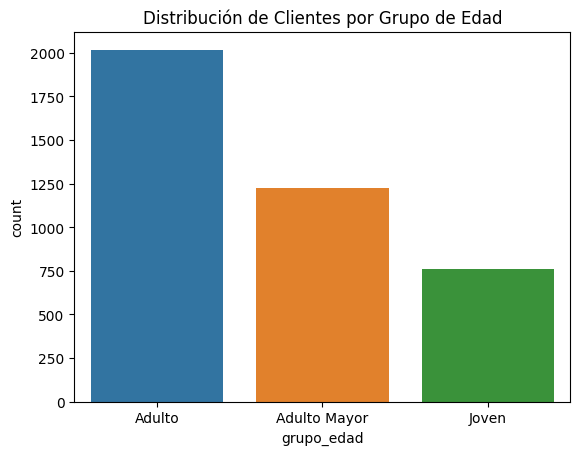

In [50]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Clientes por Grupo de Edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmente los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Los problemas de calidad en los datos que fueron corregidos antes del análisis:
-La columna 'age' contenía un valor sentinel (-999), el cual fue reemplazado por la mediana.
-La columna 'city' presentaba valores faltantes (11.7%), los cuales se mantuvieron como nulos.
-Las columnas 'duration' y 'length' tenían una alta proporción de valores nulos (>40%), pero se -determinó que estos eran MAR (Missing) At Random), ya que dependen del tipo de evento (call o text).
-Se detectaron fechas fuera de rango (año 2026), las cuales fueron corregidas como valores nulos.

🔍 **Segmentos por Edad**
La distribución de edades es relativamente uniforme, sin embargo, al incorporar la variable *grupo_edad* se identifican patrones más claros en el comportamiento de los usuarios:

- La mayoría de los usuarios se concentra en el grupo 'Adulto', seguido por 'Adulto Mayor', lo que indica que la base de clientes está compuesta principalmente por población madura.
- El plan Básico sigue predominando en todos los grupos de edad; sin embargo, en el segmento de 'Adulto Mayor' se observa una mayor participación relativa del plan Premium, lo que sugiere que este grupo podría tener mayor disposición a adquirir planes más completos.

📊 **Segmentos por Nivel de Uso**
Al incorporar la variable *grupo_uso*, se observa que:
- Los usuarios de Uso medio predominan en todos los grupos de edad.
- En 'Adulto Mayor', hay una ligera tendencia hacia niveles de uso más consistentes (menos dispersión entre bajo y alto uso), lo que podría indicar patrones de consumo más estables.
- Sin embargo, algunos usuarios de la categoría "Adultos" presentan niveles relevantes de consumo de minutos.
- No se identifican diferencias drásticas en la cantidad de mensajes o llamadas entre grupos de edad.

➡️ Esto sugiere que ...
- Los usuarios en los grupos de 'Adultos' y 'Adultos Mayores' presentan niveles relevantes de consumo de minutos, lo que indica una mayor intensidad de uso en llamadas.
- Aunque la edad no segmenta fuertemente la frecuencia de uso (mensajes y llamadas), sí muestra una relación más clara con la intensidad de consumo y una ligera inclinación hacia planes Premium en usuarios de mayor edad.
- Esto sugiere que estos segmentos podrían beneficiarse de ofertas más alineadas a su nivel de consumo.

💡 **Recomendaciones**
- *Diseñar o ajustar planes:* enfocados en usuarios *Adultos* y *Adultos Mayores*, incorporando mayores beneficios en minutos de llamadas, ya que este segmento muestra mayor intensidad de uso en este servicio.
- *Ofrecer migración a planes Premium* Identificar usuarios del plan Básico dentro de estos grupos de edad que presenten consumo medio o alto de minutos, para ofrecer la migración mediante promociones o beneficios adicionales.
- *Personalización de planes:* considerar paquetes diferenciados por segmento de edad, donde los usuarios más jóvenes puedan enfocarse en datos o mensajes, mientras que los usuarios mayores en minutos de voz.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`